#### Dataset

- Name: Iris Dataset
- Task: Unsupervised Learning - Clustering
- Source: Scikit-Learn Built-in Dataset
- Samples: 150
- Features: 4
- Reference: https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_iris.html


<h1> t-SNE (t-Distributed Stochastic Neighbor Embedding)

The main difference from PCA and SVD:

| Method | Type |
|-|-|
|PCA|Linear|
|SVD|Linear|
|t-SNE|Non-Linear|

The core idea of ​​t-SNE

The goal of t-SNE:</br>
Preserving the local structure of the data when transforming it into a low-dimensional space.

In other words:</br>
If two points are close in the original space They should also be kept close in the new space

PCA finds only a straight line.</br>
However, t-SNE can better preserve non-linear structures.

Applications of t-SNE

It is typically used for:
- Visualization
- Feature Exploration
- Embedding Analysis


For example:
- Word Embeddings
- Image Features
- Gene Expression Data

t-SNE is a visualization algorithm, not a clustering algorithm.

In [1]:
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

from sklearn.manifold import TSNE

<h3> Step 1: Test on Iris

In [2]:
iris = load_iris()

X = iris.data
y = iris.target

X_scaled = StandardScaler().fit_transform(
    X
)

In [3]:
tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42
)

In [4]:
X_tsne = tsne.fit_transform(
    X_scaled
)

c:\Users\niush\anaconda3\lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\niush\anaconda3\lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
  File "c:\Users\niush\anaconda3\lib\subprocess.py", line 503, in run
    with Popen(*popenargs, **kwargs) as process:
  File "c:\Users\niush\anaconda3\lib\subprocess.py", line 971, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\niush\anaconda3\lib\subprocess.py", line 1440, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,


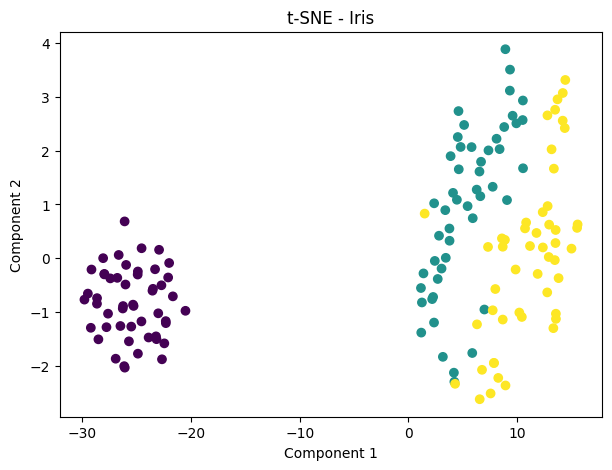

In [5]:
plt.figure(
    figsize=(7,5)
)

plt.scatter(
    X_tsne[:,0],
    X_tsne[:,1],
    c=y
)

plt.title(
    "t-SNE - Iris"
)

plt.xlabel(
    "Component 1"
)

plt.ylabel(
    "Component 2"
)

plt.show()

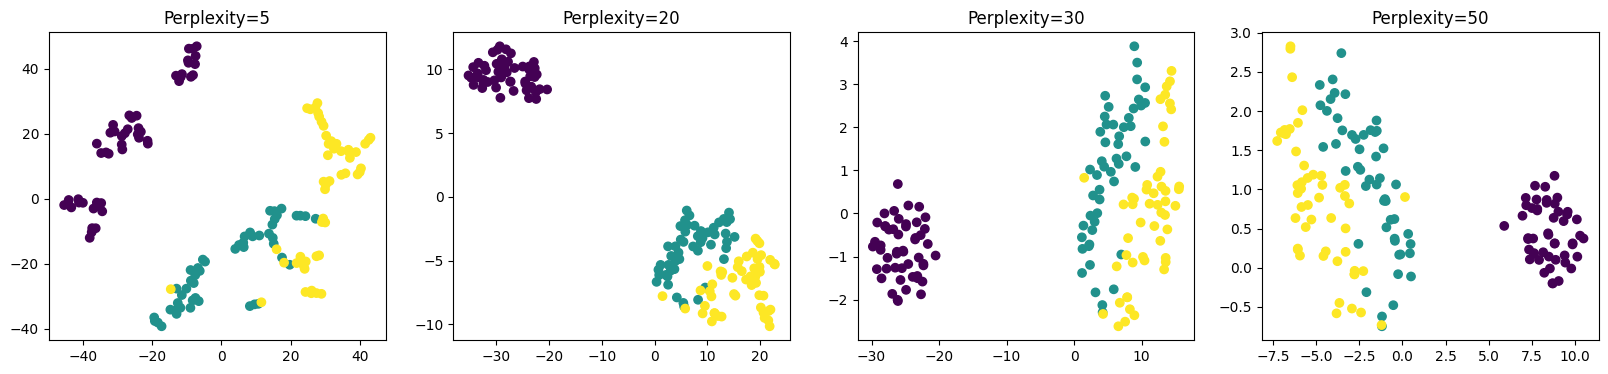

In [6]:
perplexities = [
    5,
    20,
    30,
    50
]

fig, axes = plt.subplots(
    1,
    4,
    figsize=(20,4)
)

for ax, p in zip(
    axes,
    perplexities
):

    tsne = TSNE(
        n_components=2,
        perplexity=p,
        random_state=42
    )

    X_tsne = tsne.fit_transform(
        X_scaled
    )

    ax.scatter(
        X_tsne[:,0],
        X_tsne[:,1],
        c=y
    )

    ax.set_title(
        f"Perplexity={p}"
    )

plt.show()

---
Controls the effective number of neighbors considered by the algorithm.

- Low values emphasize local structure.
- High values preserve more global relationships.
---

### Iris Dataset Results

t-SNE successfully reduced Iris data from:


4 dimensions

to:


2 dimensions

The visualization showed:

- Clear separation of Setosa.
- Partial overlap between Versicolor and Virginica.

Different perplexity values changed the embedding structure:

| Perplexity | Observation |
|---|---|
|5|More local structure, scattered clusters|
|20|Balanced representation|
|30|Clear cluster separation|
|50|More global structure|

---

### Conclusion

t-SNE is effective for visual exploration of complex datasets.

However, the generated coordinates should not be interpreted as true distances because t-SNE mainly preserves local relationships.